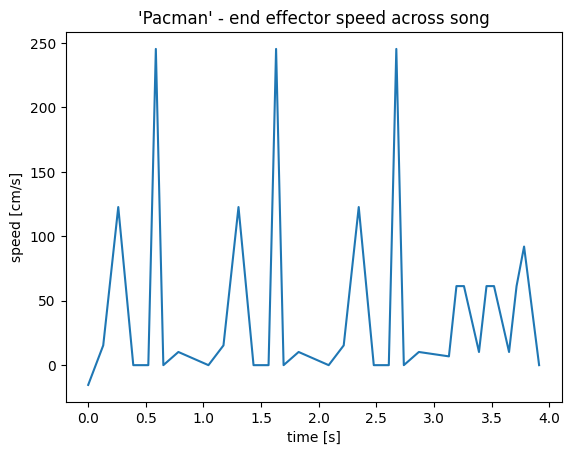

In [4]:
# ------------------------ PACKAGE IMPORTS ------------------------
import pretty_midi
import matplotlib.pyplot as plt
import importlib

# Custom Modules - must reload for module changes to reflect properly
import midi_utils
import speed_utils
import pathFinding
importlib.reload(midi_utils) 
importlib.reload(speed_utils) 

# ------------------------ CONSTANTS ------------------------
KEYS_IN_KEYBOARD = 37
PITCHES_IN_OCTAVE = 12

# song_name = "Megalovania"
song_name = "Pacman"

def get_octave(pitch):
    return int(pitch / PITCHES_IN_OCTAVE) - 1

"""
| Octave | C  | C#/Db | D  | D#/Eb | E  | F  | F#/Gb | G  | G#/Ab  | A  | A#/Bb  | B  |
|--------|----|-------|----|-------|----|----|-------|----|--------|----|--------|----|
| -1     | 0  | 1     | 2  | 3     | 4  | 5  | 6     | 7  | 8      | 9  | 10     | 11 |
| 0      | 12 | 13    | 14 | 15    | 16 | 17 | 18    | 19 | 20     | 21 | 22     | 23 |
| 1      | 24 | 25    | 26 | 27    | 28 | 29 | 30    | 31 | 32     | 33 | 34     | 35 |
| 2      | 36 | 37    | 38 | 39    | 40 | 41 | 42    | 43 | 44     | 45 | 46     | 47 |
| 3      | 48 | 49    | 50 | 51    | 52 | 53 | 54    | 55 | 56     | 57 | 58     | 59 |
| 4      | 60 | 61    | 62 | 63    | 64 | 65 | 66    | 67 | 68     | 69 | 70     | 71 |
| 5      | 72 | 73    | 74 | 75    | 76 | 77 | 78    | 79 | 80     | 81 | 82     | 83 |
| 6      | 84 | 85    | 86 | 87    | 88 | 89 | 90    | 91 | 92     | 93 | 94     | 95 |
| 7      | 96 | 97    | 98 | 99    |100 |101 |102    |103 |104     |104 |106     |107 |
| 8      |108 |109    |110 |111    |112 |113 |114    |115 |116     |117 |118     |119 |
| 9      |120 |121    |122 |123    |124 |125 |126    |127 | -      | -  | -      | -  |
"""

# Make sure that MIDI file has just a single track or otherwise do some preprocessing
notes = midi_utils.midi_to_notes(song_name)
notes = midi_utils.fit_song_into_keyboard(notes)
notes = midi_utils.make_song_staccato(notes, note_length=0.5)

midi_utils.notes_to_midi(notes, filename=f"songs/{song_name}_edit.mid")

# Extract pitches
pitches = [note.pitch for note in notes]
highest_pitch = max(pitches)
lowest_pitch  = min(pitches)

# Find lowest note and highest to make sure that the song fits on a keyboard
assert (highest_pitch - lowest_pitch < KEYS_IN_KEYBOARD)

# 47 - good for Megalovania 
# 
left_hand_notes, right_hand_notes = midi_utils.seperate_left_right(notes, PITCH_SEPARATION=47)

left_pitches  = [note.pitch for note in left_hand_notes]
right_pitches = [note.pitch for note in right_hand_notes]

# Ensures that left hand will not need to move
assert (max(left_pitches) - min(left_pitches) <= PITCHES_IN_OCTAVE)
t, speed_plt = speed_utils.calc_speed(right_hand_notes)

plt.plot(t, speed_plt)
plt.title(f"'{song_name}' - end effector speed across song")
plt.ylabel("speed [cm/s]")
plt.xlabel("time [s]")
plt.show()

In [5]:
notes

[Note(start=0.000000, end=0.065217, pitch=60, velocity=50),
 Note(start=0.000000, end=0.195652, pitch=36, velocity=50),
 Note(start=0.130435, end=0.195652, pitch=60, velocity=50),
 Note(start=0.260869, end=0.326087, pitch=67, velocity=50),
 Note(start=0.391304, end=0.456522, pitch=64, velocity=50),
 Note(start=0.391304, end=0.456522, pitch=40, velocity=50),
 Note(start=0.521739, end=0.554348, pitch=60, velocity=50),
 Note(start=0.521739, end=0.717391, pitch=36, velocity=50),
 Note(start=0.586956, end=0.619565, pitch=67, velocity=50),
 Note(start=0.652174, end=0.684782, pitch=64, velocity=50),
 Note(start=0.782608, end=0.913043, pitch=64, velocity=50),
 Note(start=0.913043, end=0.978261, pitch=40, velocity=50),
 Note(start=1.043478, end=1.108695, pitch=61, velocity=50),
 Note(start=1.043478, end=1.239130, pitch=37, velocity=50),
 Note(start=1.173913, end=1.239130, pitch=61, velocity=50),
 Note(start=1.304347, end=1.369565, pitch=68, velocity=50),
 Note(start=1.434782, end=1.500000, pitc


TIME     | CARRIAGE   | NOTE   | TYPE   | ASSIGNED FINGER
-----------------------------------------------------------------
0.00     | 54.00      | 60     | WHITE  | Finger 2 (White)
0.13     | 56.00      | 60     | WHITE  | Finger 0 (White)
0.26     | 60.00      | 67     | WHITE  | Finger 4 (White)
0.39     | 58.00      | 64     | WHITE  | Finger 2 (White)
0.52     | 56.00      | 60     | WHITE  | Finger 0 (White)
0.59     | 60.00      | 67     | WHITE  | Finger 4 (White)
0.65     | 60.00      | 64     | WHITE  | Finger 0 (White)
0.78     | 58.00      | 64     | WHITE  | Finger 2 (White)
1.04     | 54.00      | 61     | BLACK  | Finger 3 (Black)
1.17     | 56.00      | 61     | BLACK  | Finger 1 (Black)
1.30     | 62.00      | 68     | BLACK  | Finger 3 (Black)
1.43     | 60.00      | 65     | WHITE  | Finger 2 (White)
1.57     | 56.00      | 61     | BLACK  | Finger 1 (Black)
1.63     | 62.00      | 68     | BLACK  | Finger 3 (Black)
1.70     | 62.00      | 65     | WHITE  | Finger 

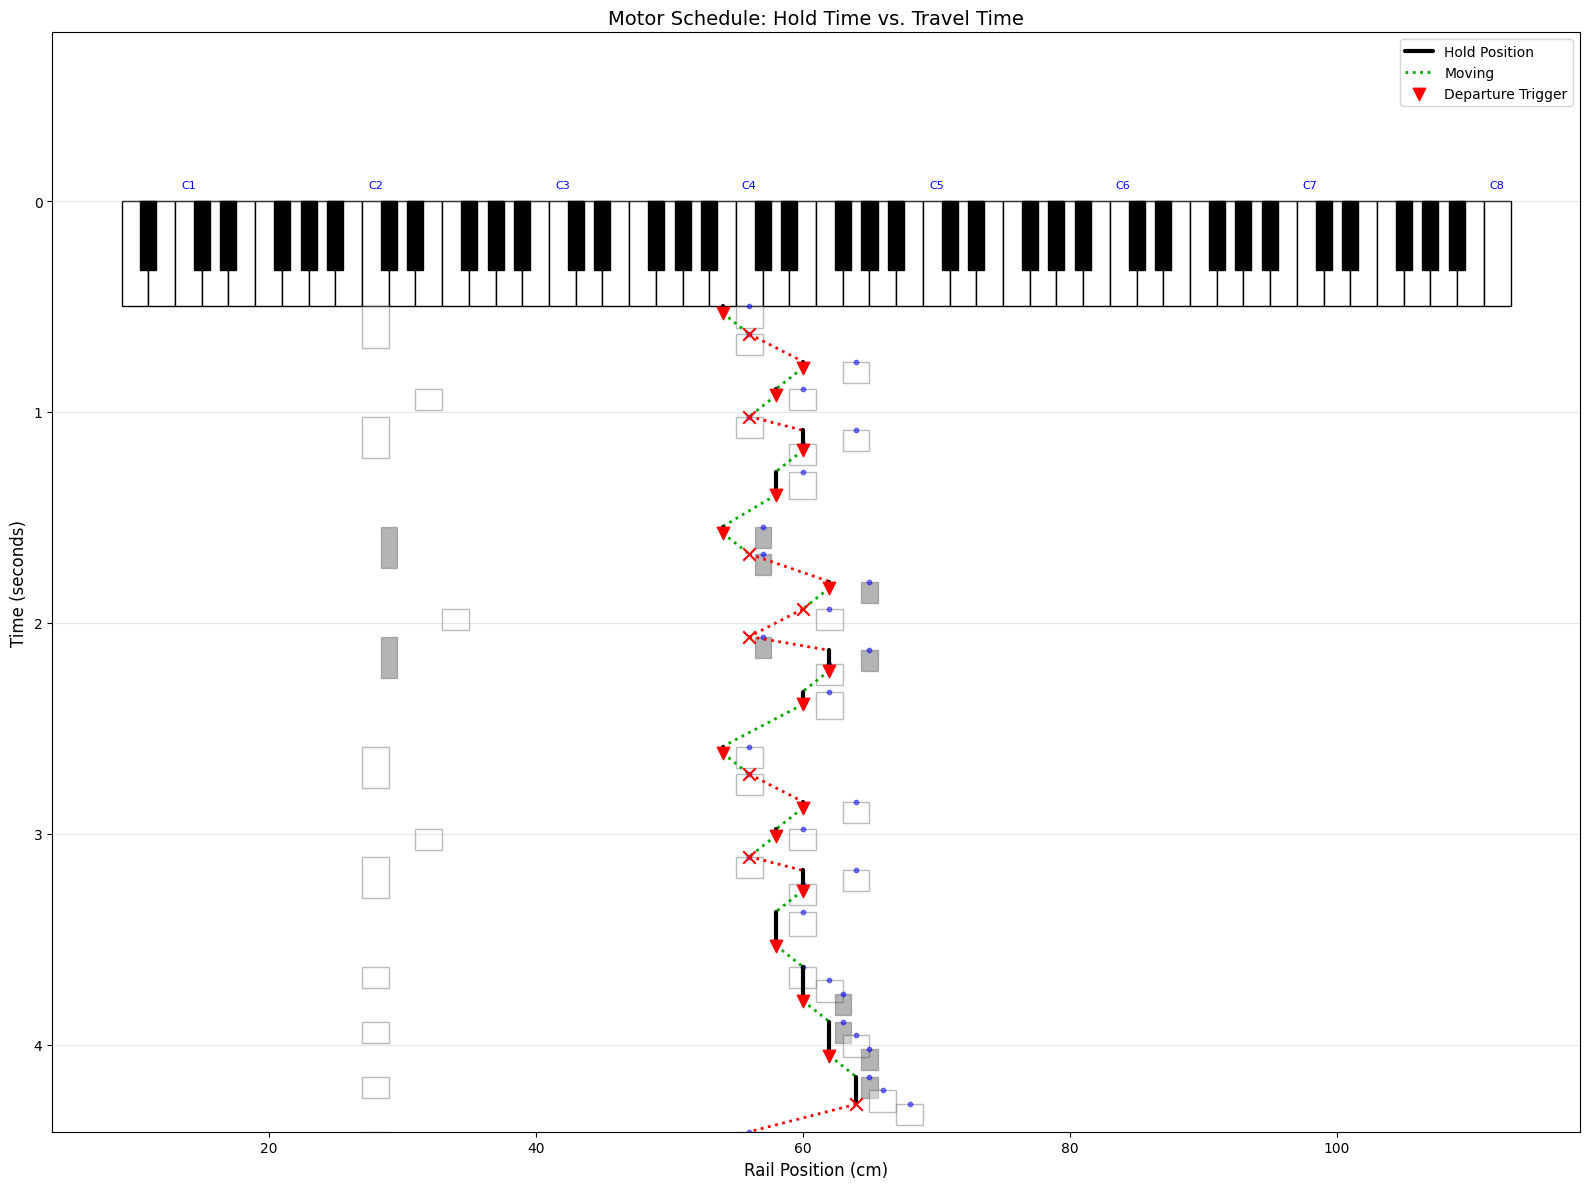

In [6]:
# 1. Run your optimization
times, path = pathFinding.find_best_time_path(notes)

# 2. Get the finger instructions
pathFinding.print_finger_assignments(times, path, right_hand_notes)

pathFinding.print_finger_assignments(times, path, notes)

pathFinding.plot_precise_movement_schedule(notes, times, path, pathFinding.ROBOT_FINGERS)